In [ ]:
import muspan as ms
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import networkx as nx
import cv2

from roifile import roiread

print("Packages loaded successfully!")

Packages loaded successfully!


In [ ]:
def ms_read(path,stage,domain_name):
    rois = roiread(f"{path}hh{stage}RoiSet.zip")
    image = cv2.imread(f'{path}hh{stage}watershed.jpg')
    height = len(image)
    width = len(image[0])

    domain = ms.domain(domain_name)
    n_limit = 10000
    n=0
    for i in rois:
        if n<n_limit:
            try:
                coords = i.coordinates()
                #take the rolling average of 5 points (interpolation)
                shape = [width,height] + [1,-1] * (coords + np.roll(coords,1,axis=0) + np.roll(coords,-1,axis=0) + np.roll(coords,-2,axis=0) + np.roll(coords,2,axis=0))/5
                domain.add_shapes([shape])    

            except Exception as e:
                print(e)
                print(i.coordinates())
            n=n+1
    return domain

In [ ]:
path = f"data/watersheds"  
stages = [3,4,5,6,8,9,10,11,12]
#stages = [5]
n=1
domain_list = []
for i in stages:
    domain = ms_read(f"{path}/{n}/",stage=i,domain_name=f"hh{i}_domain")
    #ms.visualise.visualise(domain)
    domain_list.append(domain)

In [4]:
#test circularity code
for domain in domain_list:
    test = ms.query.query(domain,("collection",),"is",f"default_collection")
    circle = ms.geometry.circularity(domain,population=test)

    for i in range(len(circle[0])):
        if circle[0][i]<0.5:
            print(circle[0][i])
            print(i)
            domain.add_objects_to_collection(add_collection_to=i, collection_name="low circularity")#,color="red")
    #ms.visualise.visualise(domain)#,color_by="collection")

0.4228338712699597
289
0.45616930213315354
416
0.4807131969514557
264
0.4958989104538405
16
0.49662409010903497
581
0.4600029085348756
631
0.49419289761240726
183
0.4526649515020733
209
0.49141806235668684
284
0.48459636306133874
96
0.4418874424649118
195
0.4892505512730158
274
0.4930470998441839
330
0.4368282314049701
484
0.4749956688425633
552
0.46303656221434086
678
0.4992270681914267
709
0.44061048782384066
852
0.44256825932115545
327
0.4312353038663277
340
0.4973100571772307
406
0.45765687762874396
645
0.4886102443776661
693
0.4214571663880415
733
0.48214123966694233
740
0.47396071032358467
782
0.4812734530426311
418
0.4979404069793576
484
0.48596681885041343
496
0.4610277902026214
587
0.399357566348613
635
0.41476819546004234
151
0.42828615042647344
181
0.4139675234712898
231
0.36466866608329324
262
0.49425383335213313
302


Domain name: hh3_domain
Number of objects: 86
Collections: ['default_collection']
Labels: ['Circularity', 'Area'] 
Networks: [] 
Distance matrices: []
(array([ 448.88000002,  667.27999998,  282.59999999, 2245.04      ,
       1410.19999999,  607.39999999,  451.96      ,   59.32      ,
       6710.20000001,  242.32      , 1391.52      , 5069.04000001,
       2653.67999998,  213.96      , 1026.8       , 1174.6       ,
        202.11999999,  296.84      ,  341.95999999,  399.48      ,
       1289.03999999,  197.6       ,  220.72      ,   98.2       ,
        149.56      ,  219.96      , 1910.72000001,  228.28      ,
        300.88      ,  168.48      ,  114.84      ,   31.24      ,
        343.        , 1434.4       ,  832.84      ,  529.68      ,
        268.08      ,  888.        ,  369.96      ,  620.56      ,
        319.24      ,   64.24      ,  726.88      , 1298.32      ,
        921.4       ,  387.12      ,  234.6       ,  676.8       ,
        504.6       ,   77.32      ,  209.52

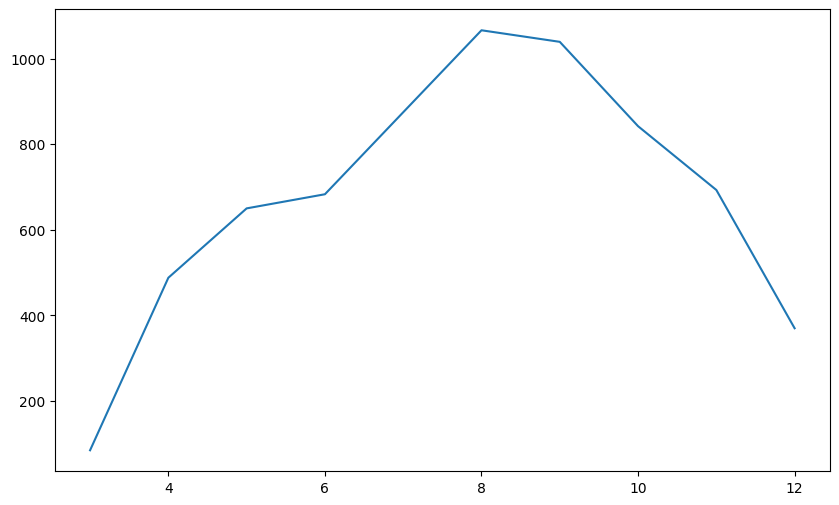

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
areas = []
for domain in domain_list:
#for i in range(1):
    #domain = domain_list[i]
    print(domain)
    print(ms.geometry.area(domain))
    areas.append(len(ms.query.get_labels(domain,"Area")[0]))

#ax.violinplot(areas,stages)
#ax.set_yscale('log', base=2)
plt.plot(stages,areas)